In [23]:
from langchain_core.messages import SystemMessage, HumanMessage
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import operator

In [24]:
load_dotenv()
model=ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview")

In [25]:
def extract_text(content):
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts = []
        for item in content:
            if isinstance(item, dict) and "text" in item:
                parts.append(item["text"])
            else:
                parts.append(str(item))
        return "".join(parts)
    return str(content)

In [26]:
class TweetEvaluation(BaseModel):
    evaluation:Literal["Approved","Needs_Improvement"]=Field(...,description="Final evaluation result.")
    feedback: str= Field(...,description="feedback for the tweet.")

In [27]:
evaluation_model=model.with_structured_output(TweetEvaluation)

In [28]:
class TweetState(TypedDict):
    topic:str
    tweet:str
    evaluation: Literal["Approved","Needs_Improvement"]
    feedback: str
    iteration:int 
    max_iteration:int 
    
    tweet_history:Annotated[list[str],operator.add]
    feedback_history:Annotated[list[str],operator.add]
    

In [29]:
def generate_tweet(state: TweetState) -> TweetState:

    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
            Write a short, original, and hilarious tweet on the topic: \"{state['topic']}\".

            Rules:
            - Do NOT use question-answer format.
            - Max 280 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
        """)
    ]

    response = model.invoke(messages)
    tweet_text = extract_text(response.content)

    return {"tweet": tweet_text, "tweet_history": [tweet_text]}

In [30]:
def evaluate_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
        HumanMessage(content=f"""
            Evaluate the following tweet:

            Tweet: \"{state['tweet']}\"

            Use the criteria below to evaluate the tweet:

            1. Originality - Is this fresh, or have you seen it a hundred times before?
            2. Humor - Did it genuinely make you smile, laugh, or chuckle?
            3. Punchiness - Is it short, sharp, and scroll-stopping?
            4. Virality Potential - Would people retweet or share it?
            5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

            Auto-reject if:
            - It's written in question-answer format (e.g., \"Why did...\" or \"What happens when...\")
            - It exceeds 280 characters
            - It reads like a traditional setup-punchline joke
            - Do not end with generic, throwaway, or deflating lines that weaken the humor

            Respond ONLY in structured format:
            - evaluation: \"Approved\" or \"Needs_Improvement\"
            - feedback: One paragraph explaining the strengths and weaknesses
        """)
    ]

    response = evaluation_model.invoke(messages)

    return {
        "evaluation": response.evaluation,
        "feedback": response.feedback,
        "feedback_history": [response.feedback]
    }

In [31]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
            Improve the tweet based on this feedback:
            \"{state['feedback']}\"

            Topic: \"{state['topic']}\"
            Original Tweet:
            {state['tweet']}

            Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
    ]

    response = model.invoke(messages)
    tweet_text = extract_text(response.content)
    iteration = state['iteration'] + 1

    return {"tweet": tweet_text, "iteration": iteration, "tweet_history": [tweet_text]}

In [32]:
def route_evaluation(state:TweetState):
    
    if state['evaluation']=='Approved' or state['iteration'] >= state['max_iteration']:
        return "Approved"
    else:
        return "Needs_Improvement"

In [33]:
# Graph
graph=StateGraph(TweetState)

# Add Nodes
graph.add_node("generate_tweet",generate_tweet)
graph.add_node("evaluate_tweet",evaluate_tweet)
graph.add_node("optimize_tweet",optimize_tweet)

# Add Edges
graph.add_edge(START,"generate_tweet")
graph.add_edge("generate_tweet","evaluate_tweet")

graph.add_conditional_edges("evaluate_tweet",route_evaluation,{'Approved':END,"Needs_Improvement":'optimize_tweet'})
graph.add_edge('optimize_tweet','evaluate_tweet')

# Compile Tweet
workflow=graph.compile()

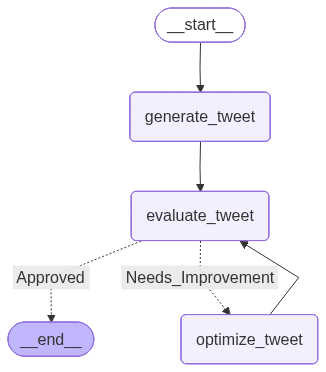

In [34]:
workflow

In [35]:
initial_state = {
    "topic": "College Life in India",
    "iteration": 1,
    "max_iteration": 5,
    "tweet_history": [],
    "feedback_history": []
}
result = workflow.invoke(initial_state)

In [36]:
print("Final Tweet:\n", result["tweet"])
print("\nEvaluation:", result["evaluation"])
print("\nFinal Feedback:\n", result["feedback"])
print("\nTweet Iterations:", len(result.get("tweet_history", [])))
print("\nTweet History:")
for i, t in enumerate(result.get("tweet_history", []), start=1):
    print(f"{i}. {t}")

Final Tweet:
 Indian college isn’t an education; it’s a 4-year stress test to see how much pointless paperwork you can tolerate before the real job starts. We’re literally paying lakhs just to audition for the privilege of being a miserable corporate cog.

Evaluation: Needs_Improvement

Final Feedback:
 While the sentiment is relatable, it suffers from severe lack of originality; the 'college is a scam/stress test' trope has been exhausted by countless accounts. It lacks a clever twist or a unique observational angle, reading more like a generic vent session than a viral tweet. The tone is overly cynical without the necessary sharp wit to make it memorable, and it feels like a tired reiteration of every other post in the academic-cynicism niche.

Tweet Iterations: 5

Tweet History:
1. College life in India is just 4 years of pretending you’re an entrepreneur, living on Maggi, and attending a 9 AM lecture you have zero intention of understanding, just to keep that attendance percentage 